# Evaluation vs random and alpha-beta opponents

Two sections: first vs **random**, then vs **alpha-beta-4 + piece-square table**.
Each ablation has its own cell within each section.

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
def plot_eval(json_path: str, opponent_label: str, title_suffix: str = '', smooth_window: int = 6):
    with open(json_path) as f:
        data = json.load(f)
    if not data:
        print(f'{json_path}: empty')
        return
    iterations = [d['iteration'] for d in data]
    n_games = data[0]['wins'] + data[0]['draws'] + data[0]['losses']
    win_rate  = [d['wins']   / n_games * 100 for d in data]
    draw_rate = [d['draws']  / n_games * 100 for d in data]
    loss_rate = [d['losses'] / n_games * 100 for d in data]
    score_pct = [d['score_pct'] for d in data]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax1.stackplot(iterations, win_rate, draw_rate, loss_rate,
                  labels=['Win', 'Draw', 'Loss'],
                  colors=['#2ecc71', '#95a5a6', '#e74c3c'], alpha=0.8)
    ax1.set_ylabel('Rate (%)')
    ax1.set_title(f'Model vs {opponent_label} ({n_games} games per checkpoint) — {title_suffix}')
    ax1.legend(loc='upper right')
    ax1.set_ylim(0, 100)

    if len(score_pct) >= smooth_window:
        kernel = np.ones(smooth_window) / smooth_window
        score_smooth = np.convolve(score_pct, kernel, mode='valid')
        offset = smooth_window // 2
        iter_smooth = iterations[offset : offset + len(score_smooth)]
        ax2.plot(iter_smooth, score_smooth, color='#2c3e50', linewidth=2,
                 label=f'Smoothed (window={smooth_window})')
    ax2.plot(iterations, score_pct, alpha=0.3, color='#3498db', label='Raw')
    ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
    ax2.axhline(y=95, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('Training Iteration')
    ax2.set_ylabel('Score %')
    ax2.set_title(f'Score % vs {opponent_label} (win=100, draw=50, loss=0) — {title_suffix}')
    ax2.legend(loc='lower right')
    ax2.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()


---
# Section 1 — vs Random


## Ablation 1 — Baseline (buffer 30k, gate 20, steps 150) — vs Random

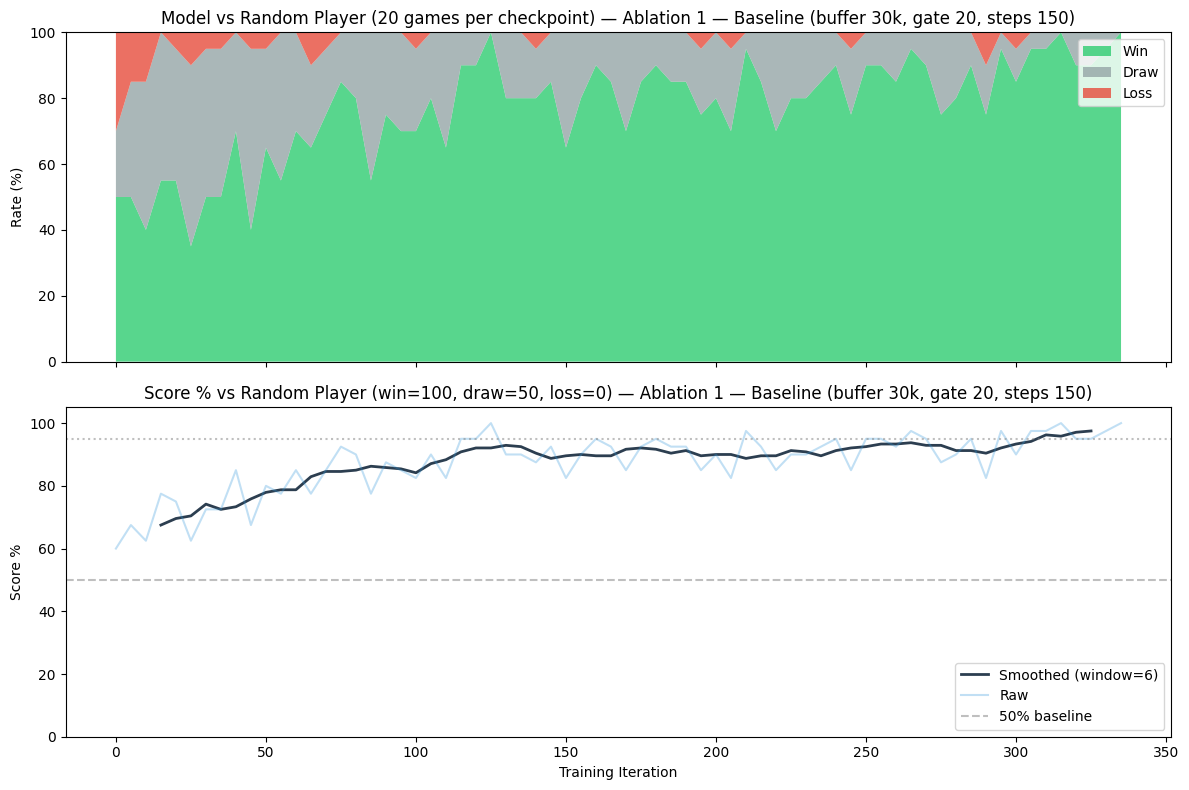

In [ ]:
plot_eval('results/abl1_baseline/eval_vs_random_best.json', 'Random Player', 'Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)')

## Ablation 2 — Buffer 10k — vs Random

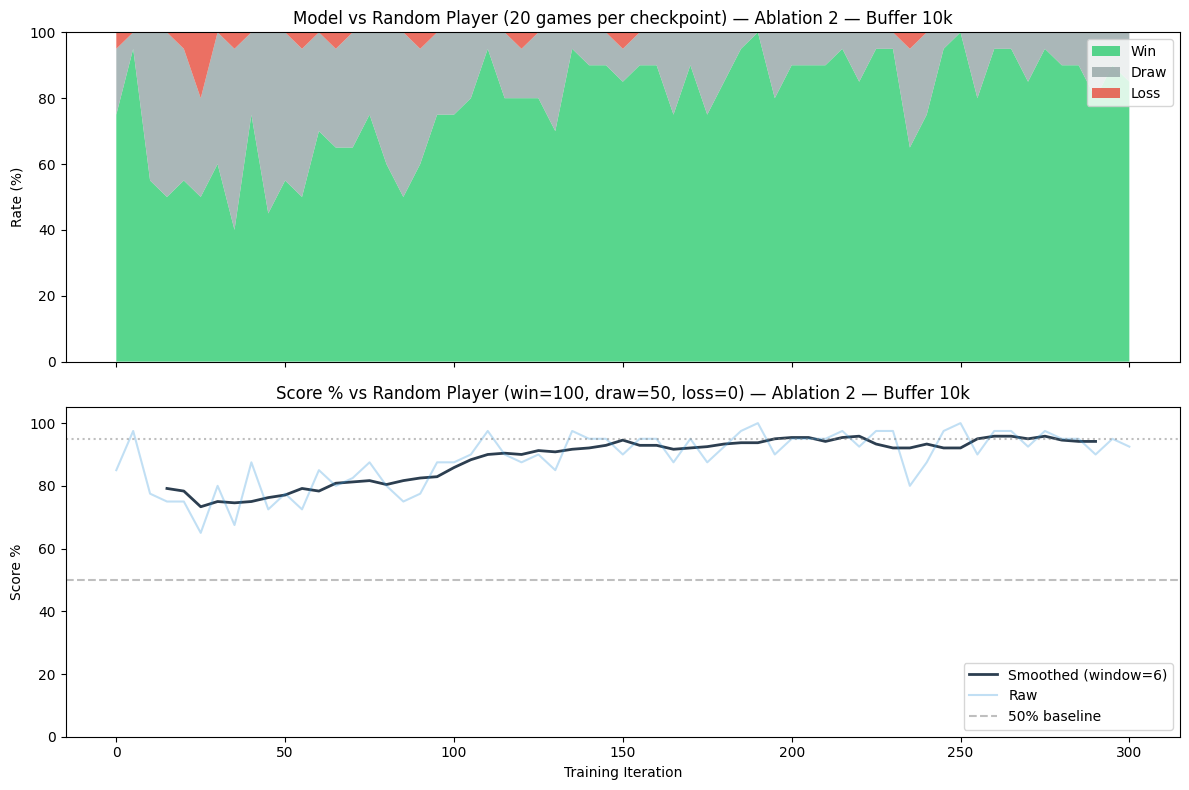

In [ ]:
plot_eval('results/abl2_buffer_10k/eval_vs_random_best.json', 'Random Player', 'Ablation 2 — Buffer 10k')

## Ablation 3 — Buffer 3k — vs Random

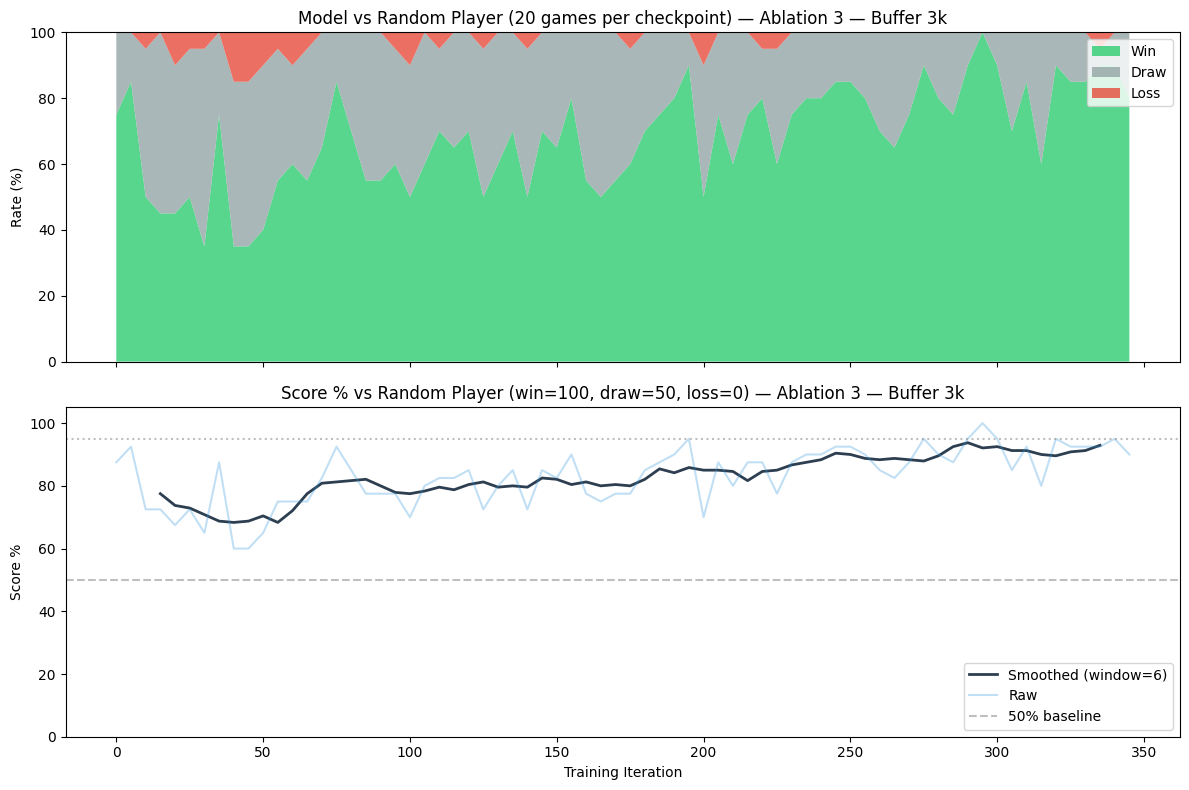

In [ ]:
plot_eval('results/abl3_buffer_3k/eval_vs_random_best.json', 'Random Player', 'Ablation 3 — Buffer 3k')

## Ablation 4 — Gate 50 games — vs Random

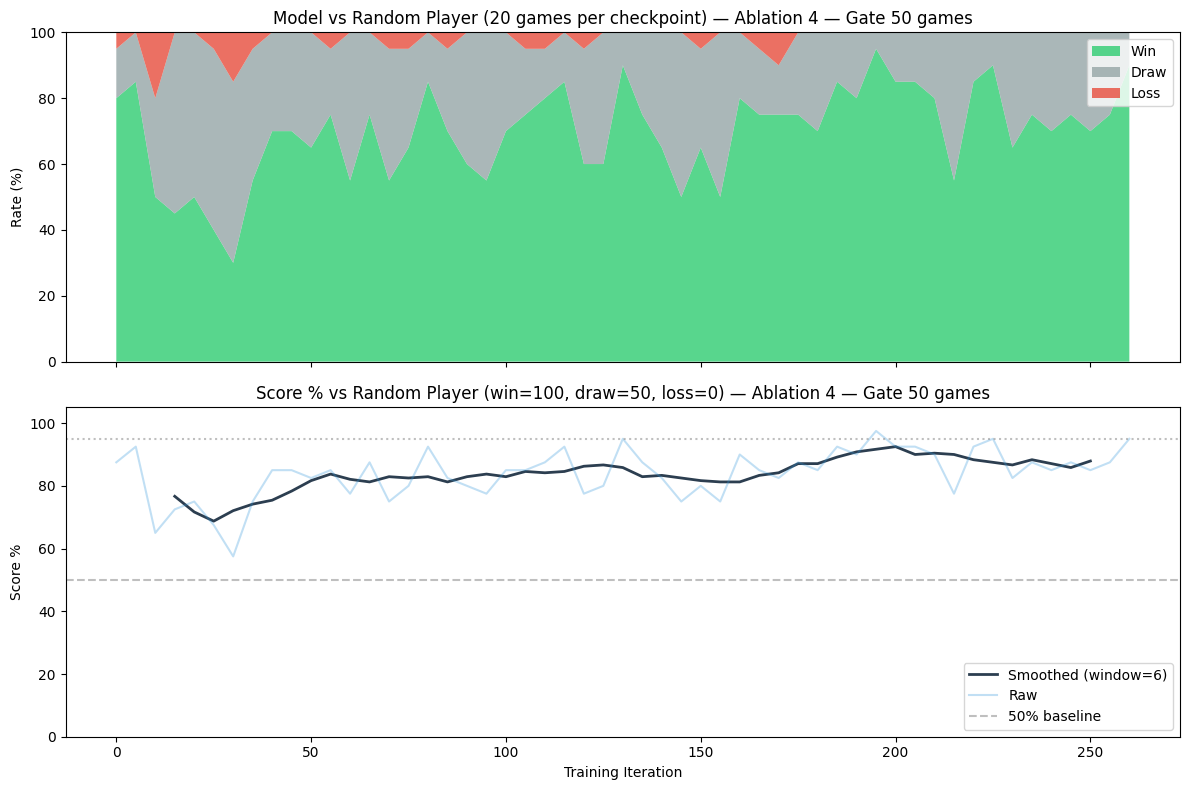

In [ ]:
plot_eval('results/abl4_gate_50/eval_vs_random_best.json', 'Random Player', 'Ablation 4 — Gate 50 games')

## Ablation 5 — Gate 120 games — vs Random

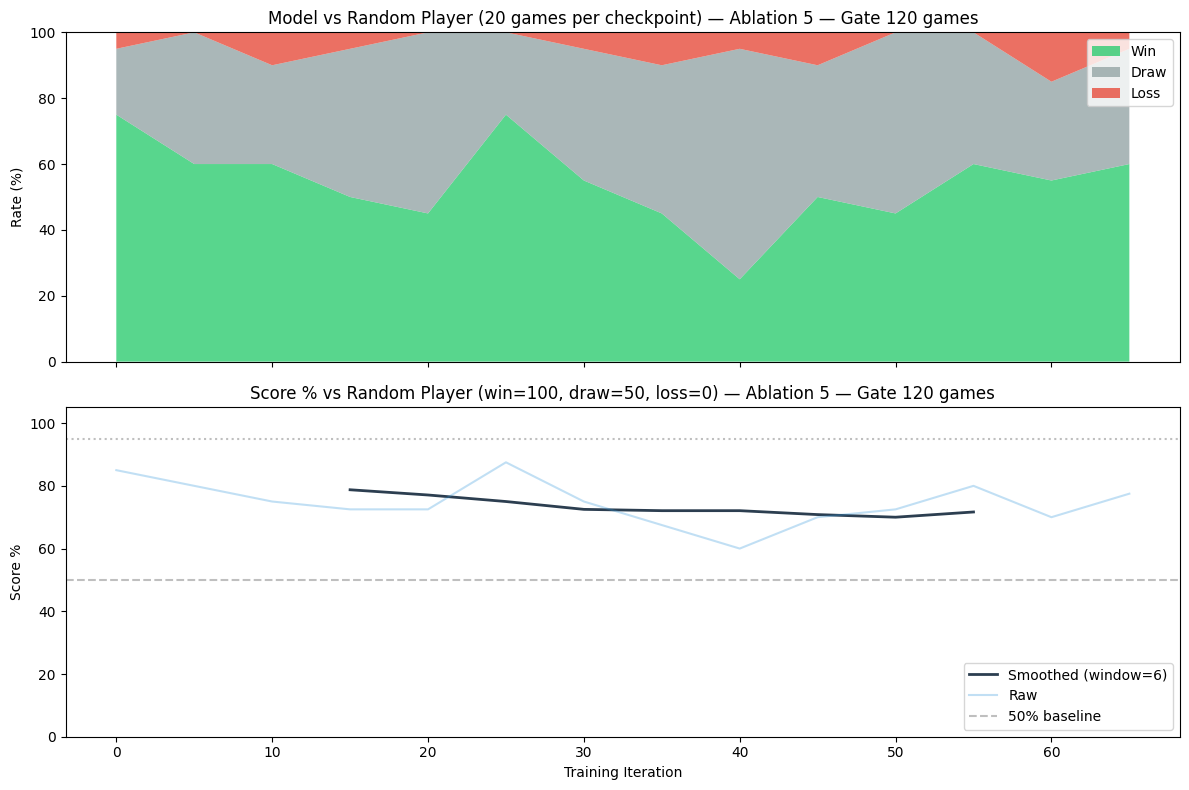

In [ ]:
plot_eval('results/abl5_gate_120/eval_vs_random_best.json', 'Random Player', 'Ablation 5 — Gate 120 games')

## Ablation 6 — Steps 50/iter — vs Random

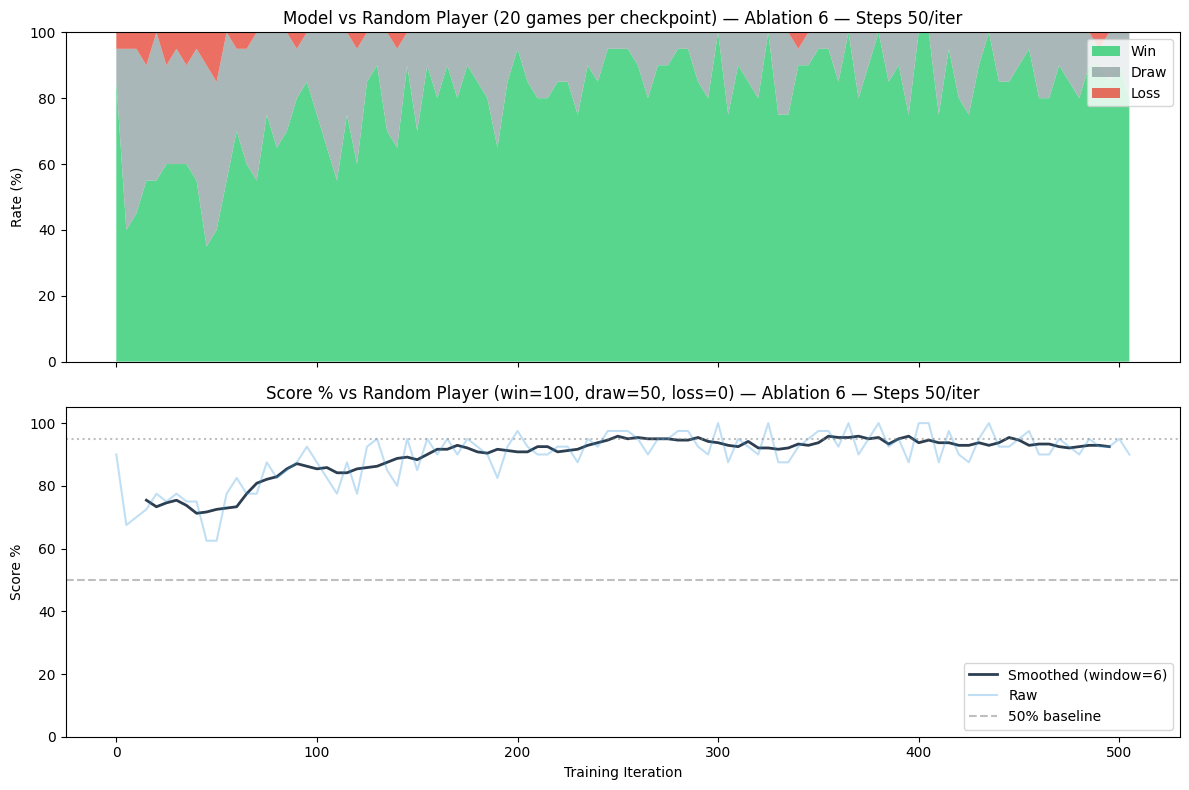

In [ ]:
plot_eval('results/abl6_steps_50/eval_vs_random_best.json', 'Random Player', 'Ablation 6 — Steps 50/iter')

## Ablation 7 — Steps 100/iter — vs Random

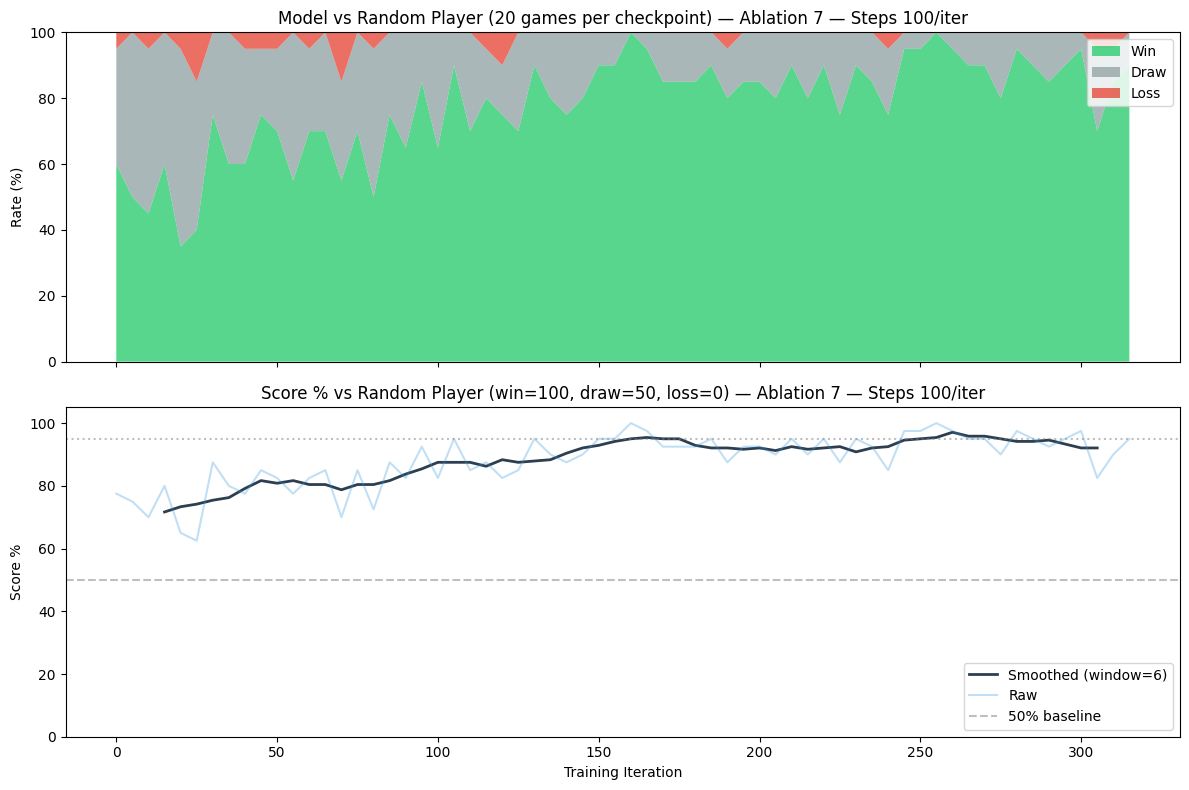

In [ ]:
plot_eval('results/abl7_steps_100/eval_vs_random_best.json', 'Random Player', 'Ablation 7 — Steps 100/iter')

## SGD gate run (long baseline, ~890 iters) — vs Random

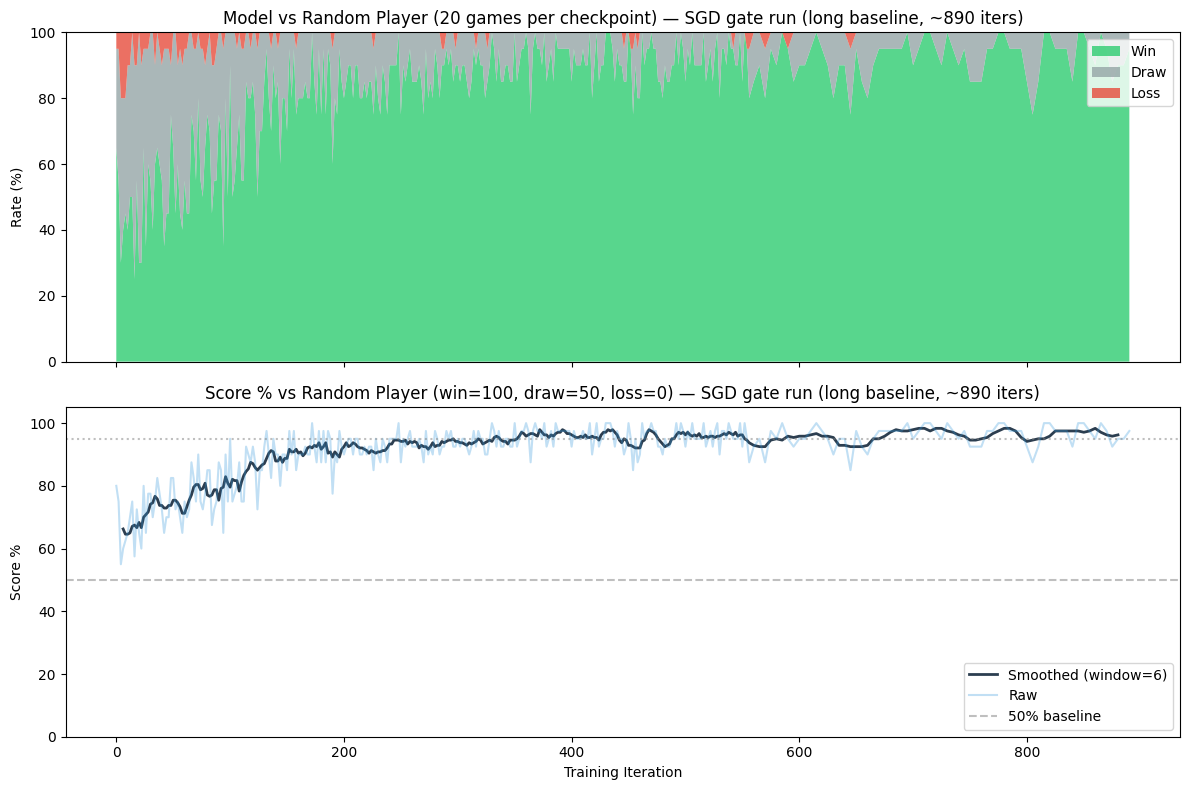

In [ ]:
plot_eval('results/sgd_gate_run/eval_vs_random_best.json', 'Random Player', 'SGD gate run (long baseline, ~890 iters)')

---
# Section 2 — vs Alpha-Beta (depth 4 + piece-square table)


## Ablation 1 — Baseline (buffer 30k, gate 20, steps 150) — vs Alpha-Beta-4

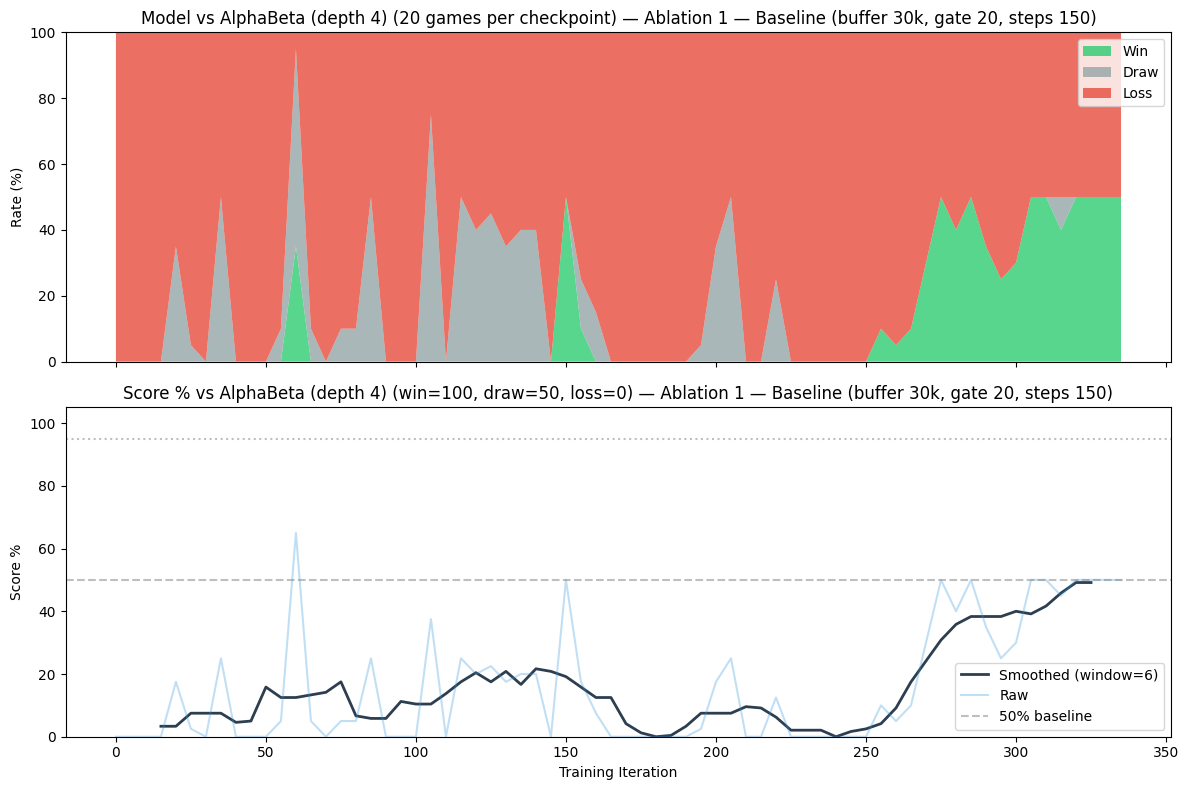

In [ ]:
plot_eval('results/abl1_baseline/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)')

## Ablation 2 — Buffer 10k — vs Alpha-Beta-4

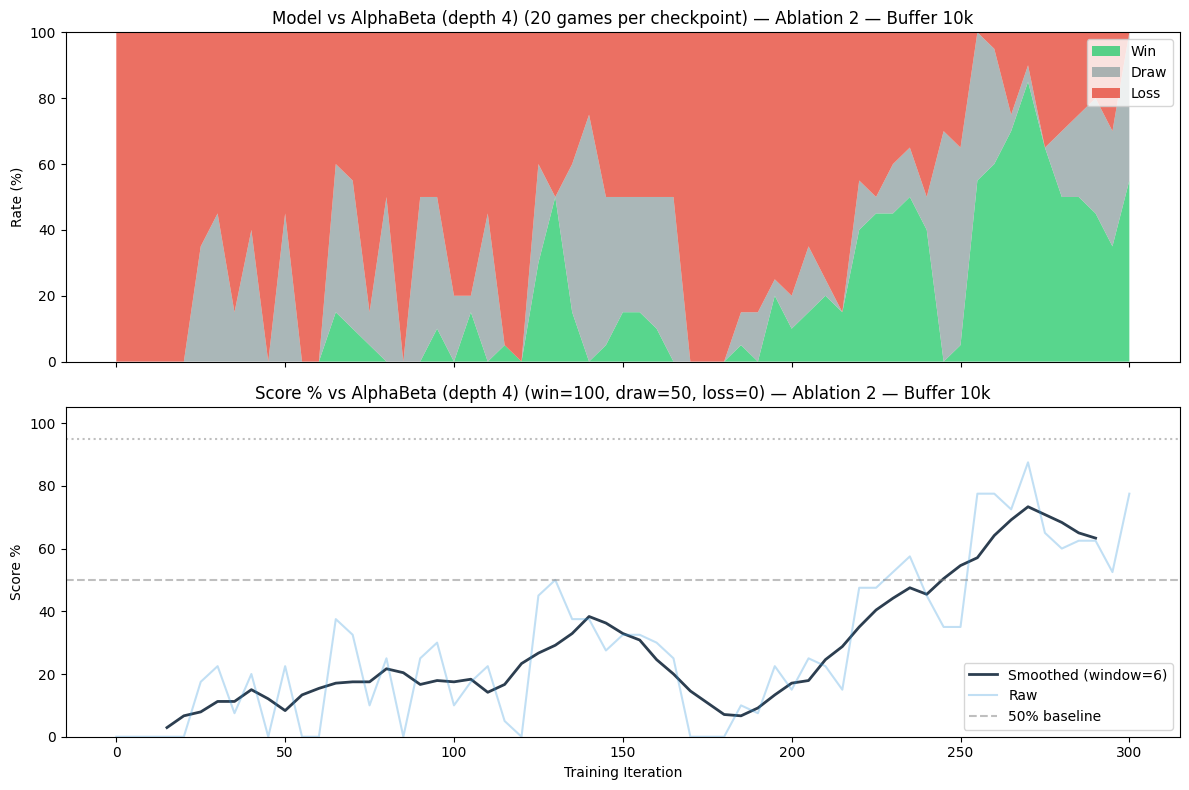

In [ ]:
plot_eval('results/abl2_buffer_10k/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 2 — Buffer 10k')

## Ablation 3 — Buffer 3k — vs Alpha-Beta-4

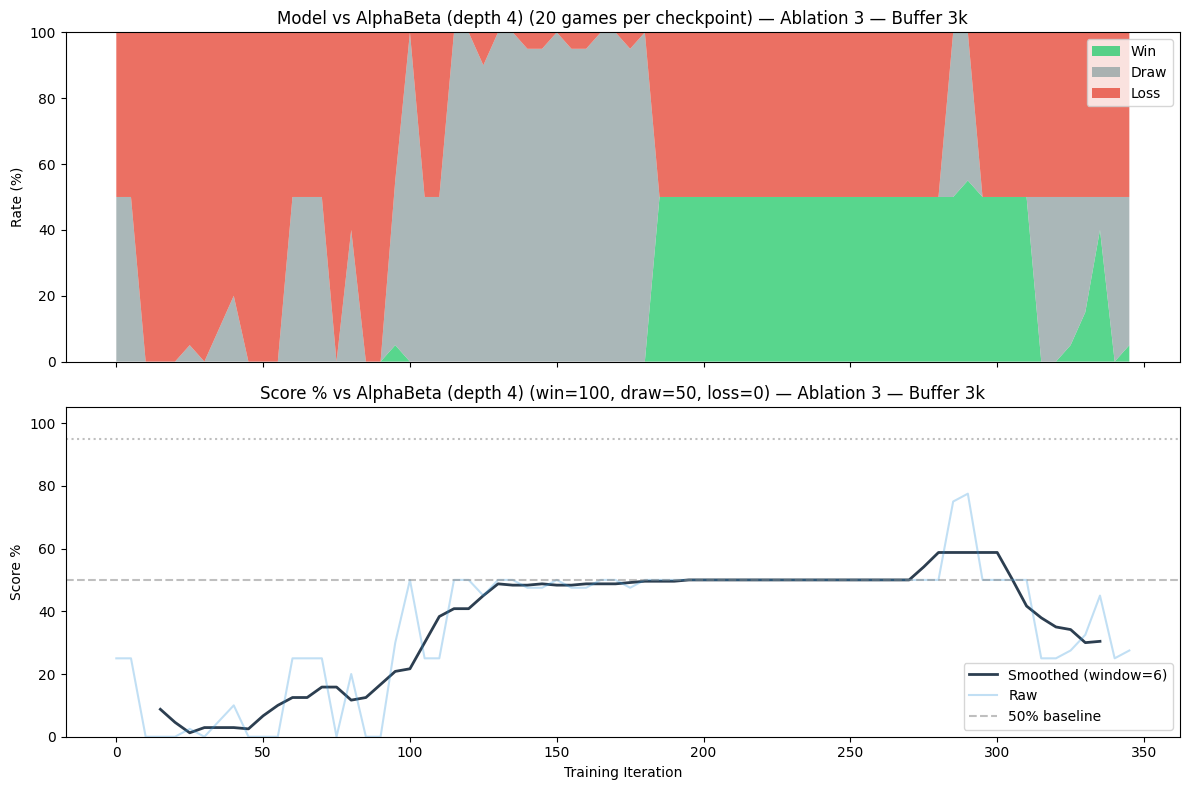

In [ ]:
plot_eval('results/abl3_buffer_3k/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 3 — Buffer 3k')

## Ablation 4 — Gate 50 games — vs Alpha-Beta-4

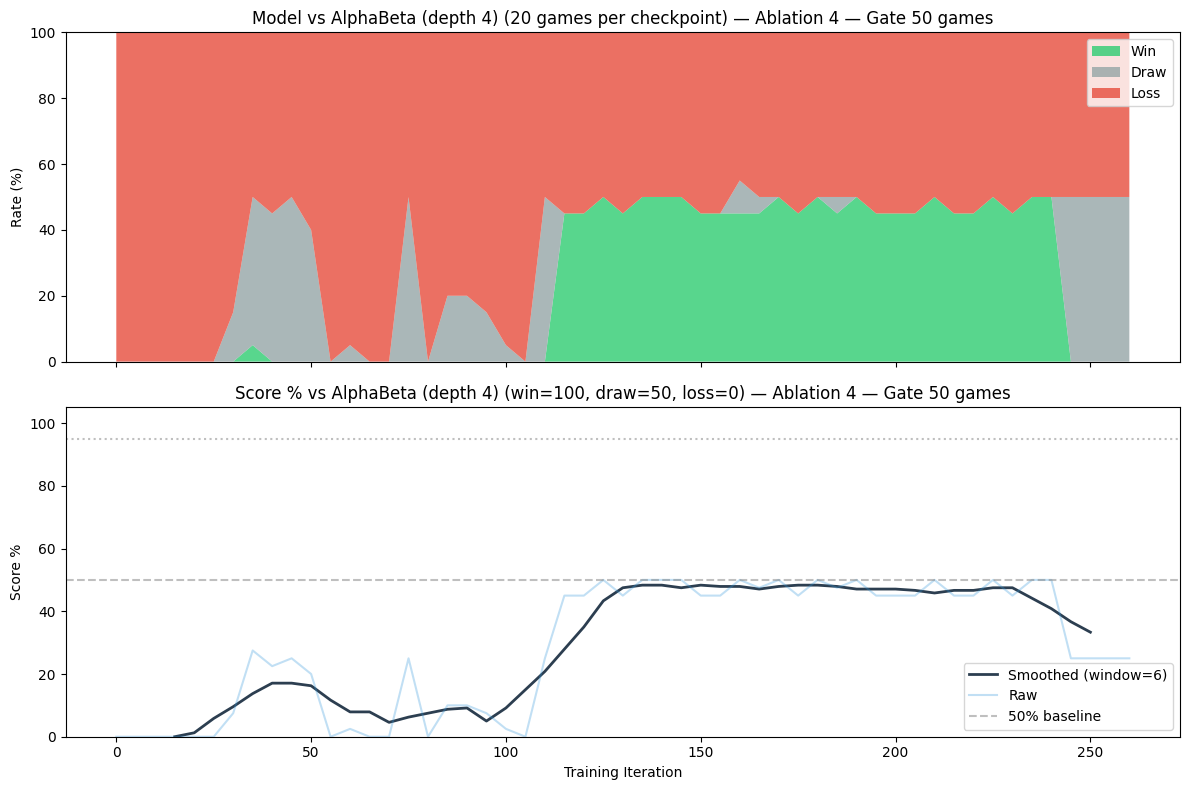

In [ ]:
plot_eval('results/abl4_gate_50/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 4 — Gate 50 games')

## Ablation 5 — Gate 120 games — vs Alpha-Beta-4

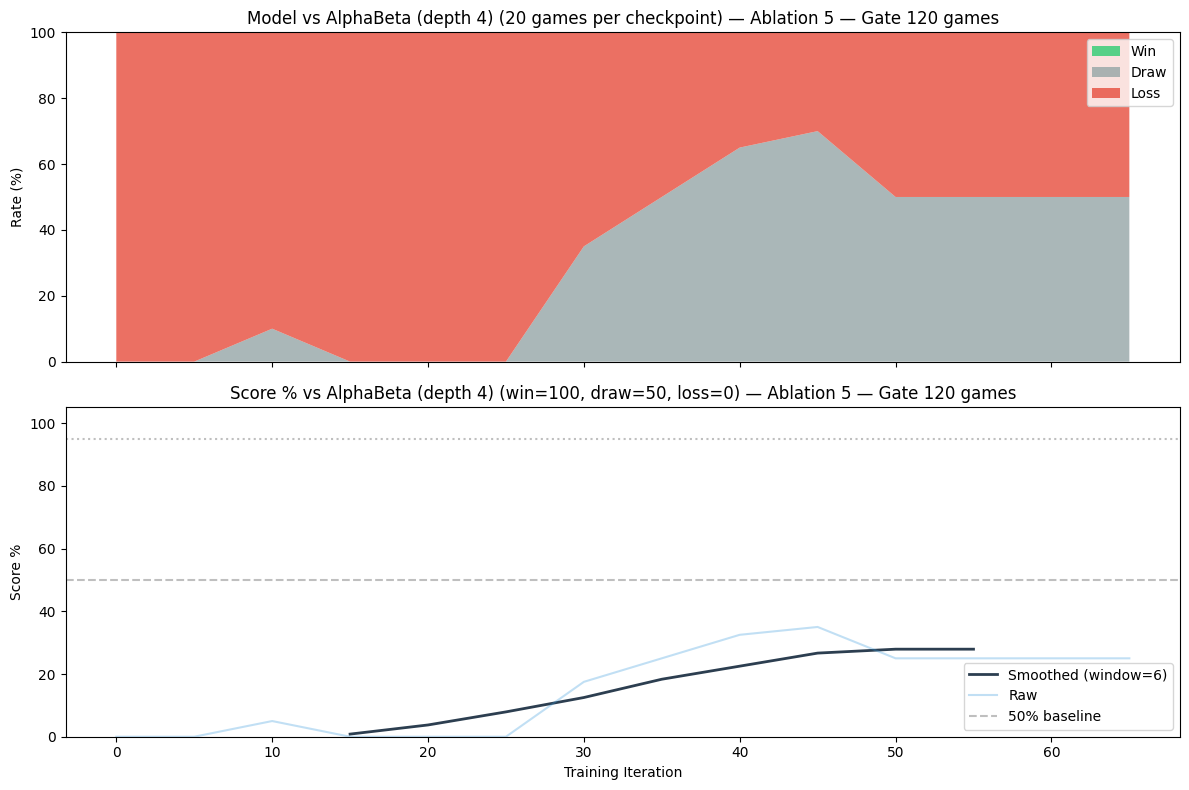

In [ ]:
plot_eval('results/abl5_gate_120/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 5 — Gate 120 games')

## Ablation 6 — Steps 50/iter — vs Alpha-Beta-4

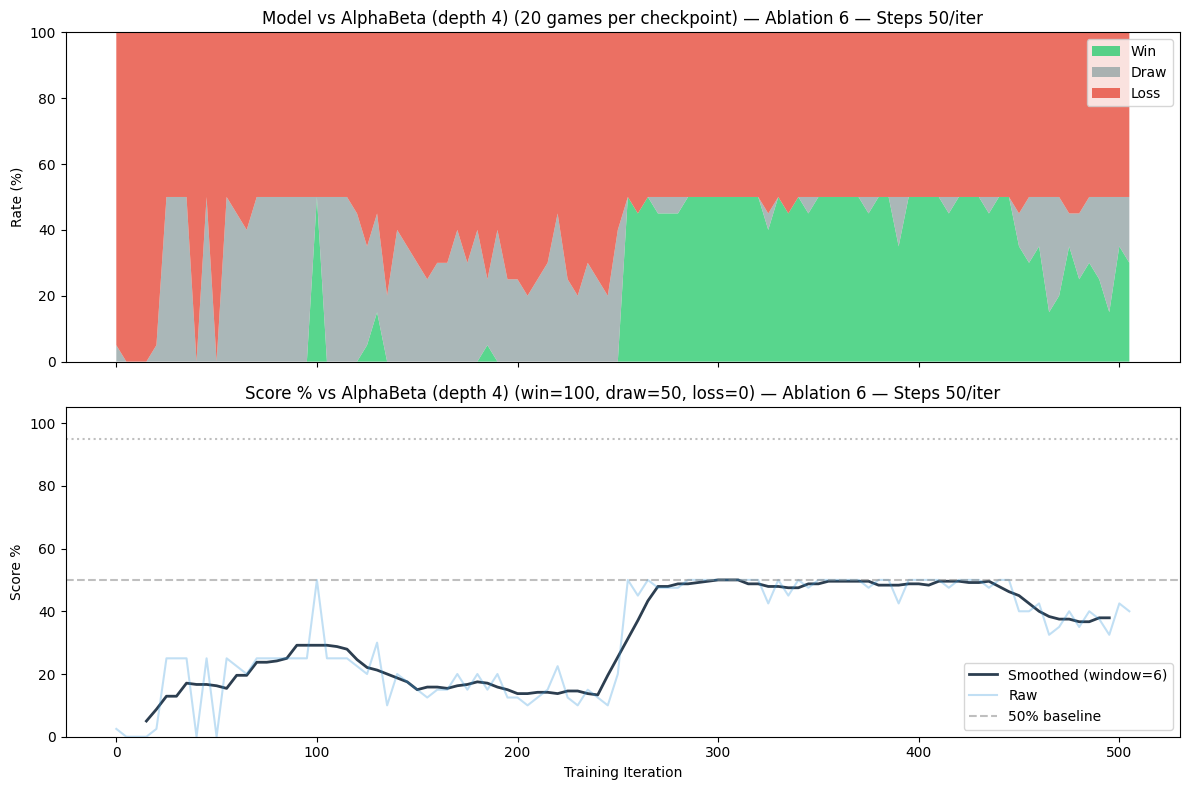

In [ ]:
plot_eval('results/abl6_steps_50/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 6 — Steps 50/iter')

## Ablation 7 — Steps 100/iter — vs Alpha-Beta-4

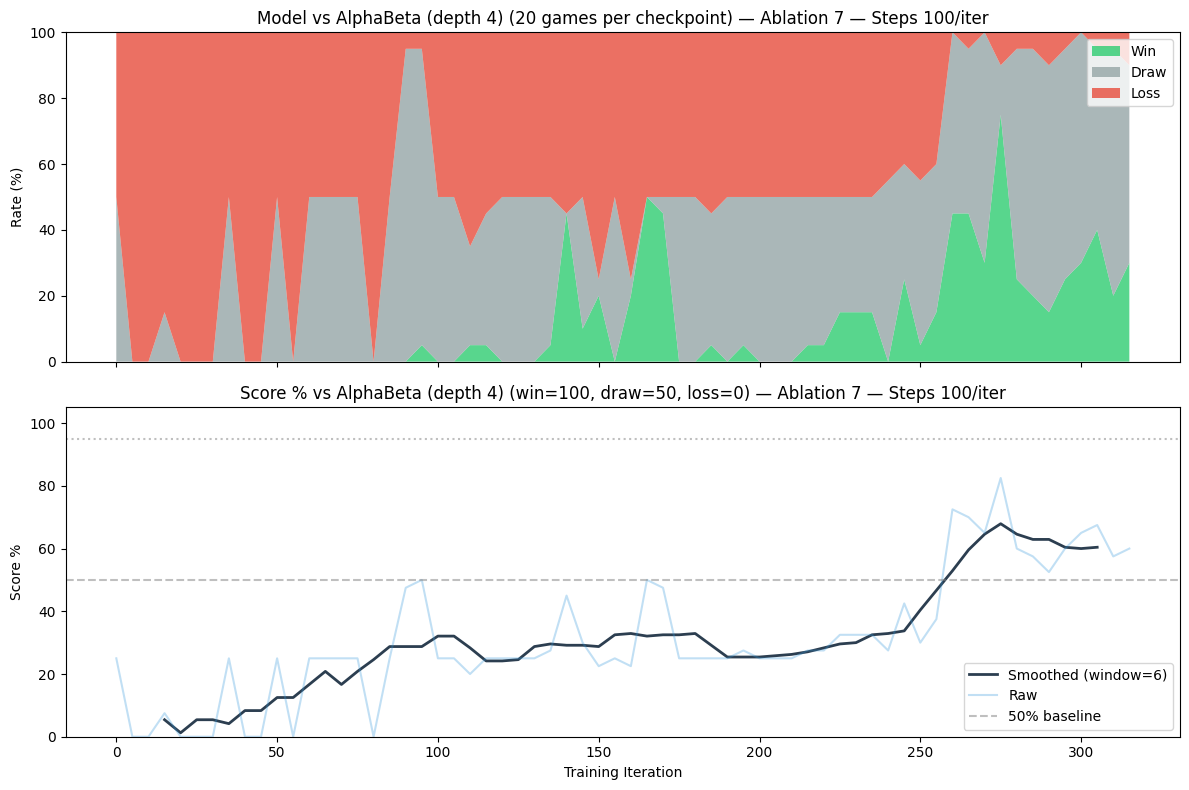

In [ ]:
plot_eval('results/abl7_steps_100/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'Ablation 7 — Steps 100/iter')

## SGD gate run (long baseline, ~890 iters) — vs Alpha-Beta-4

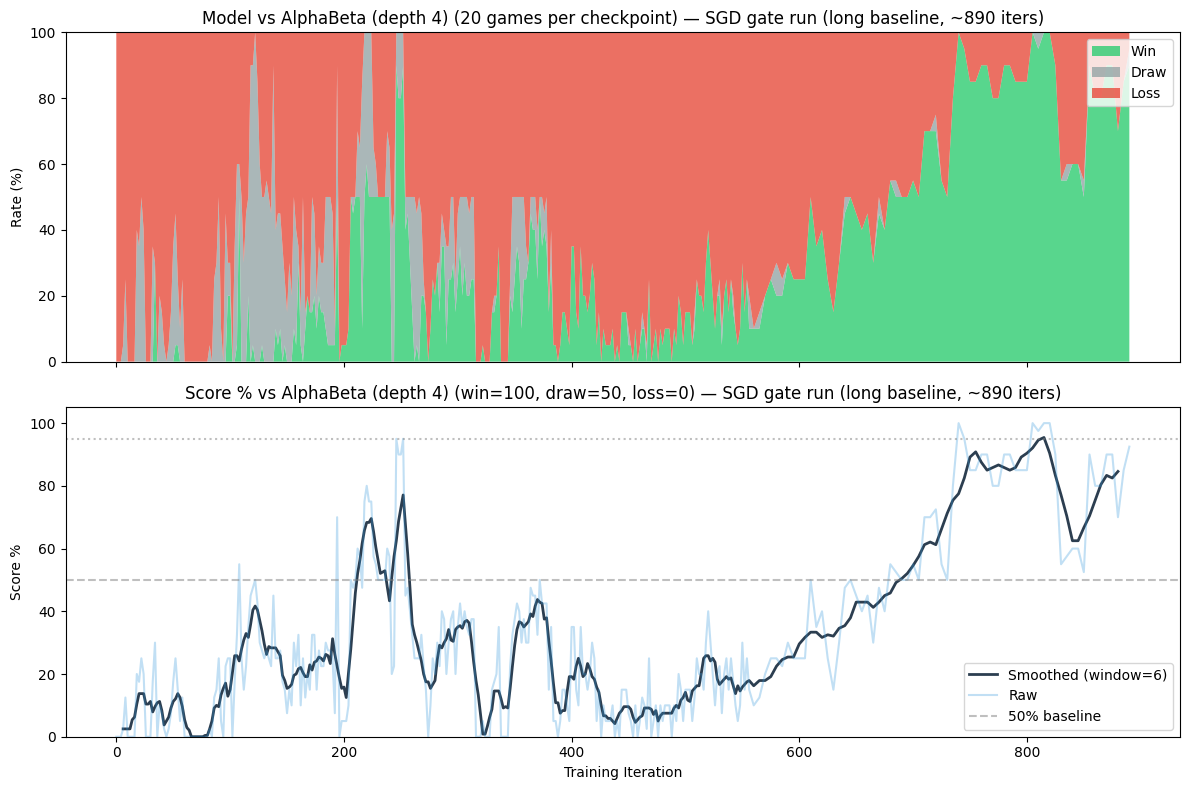

In [ ]:
plot_eval('results/sgd_gate_run/eval_vs_alphabeta_n_d4_best.json', 'AlphaBeta (depth 4)', 'SGD gate run (long baseline, ~890 iters)')